In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
source = "/Users/hades/Desktop/Bruchas Lab/Encoder_Decoder/DJM_binary_classification/Relate_Terminal_to_NAc/signal_data"
files = sorted([f for f in os.listdir(source) if f.endswith(".npy")])
full_paths = [os.path.join(source, f) for f in files]
np_arrs = [np.load(f) for f in full_paths]

nac1 = np_arrs[0]
nac2 = np_arrs[1]
nac3 = np_arrs[2]
nac4 = np_arrs[3]
nac5 = np_arrs[4]
terminal = np_arrs[5]

clusters = [
    nac1,
    nac2,
    nac3,
    nac4,
    nac5
]

sampling_rate = 700/71

In [3]:
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data)

def calculate_psi(phase1, phase2):
    complex_phase_diff = np.exp(1j*(phase1 - phase2))
    return np.abs(np.mean(complex_phase_diff))

def generate_surrogate(phase):
    fft = np.fft.fft(phase)
    random_phases = np.exp(1j * np.random.uniform(0, 2*np.pi, len(phase)))
    fft_surrogate = fft * random_phases
    return np.angle(np.fft.ifft(fft_surrogate))

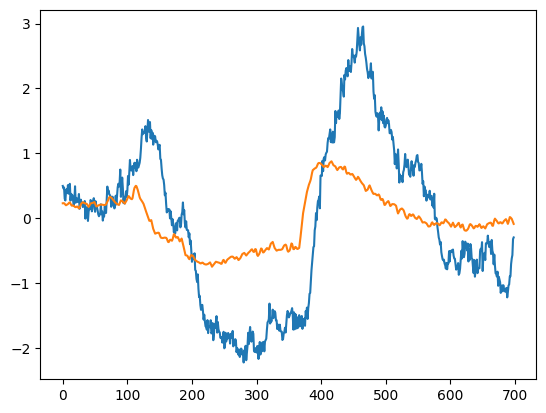

0.6031854427909592

In [5]:
filtered1 = bandpass_filter(nac5, 0.01, 4.92, sampling_rate, 5)
filtered2 = bandpass_filter(terminal, 0.01, 4.92, sampling_rate, 5)
plt.plot(filtered1)
plt.plot(filtered2)
plt.show()

calculate_psi(filtered1, filtered2)

In [6]:
sampling_rate = 700/71
lowcut = 0.01
highcut = 4.92

filtered_terminal = bandpass_filter(terminal, lowcut, highcut, sampling_rate, 5)
terminal_phase = np.angle(signal.hilbert(filtered_terminal))

for i, cluster in enumerate(clusters, start=1):
    filtered_cluster = bandpass_filter(cluster, lowcut, highcut, sampling_rate, 5)
    cluster_phase = np.angle(signal.hilbert(filtered_cluster))

    psi = calculate_psi(terminal_phase, cluster_phase)

    n_surrogates = 1000
    surrogate_psi = np.zeros(n_surrogates)

    for j in range(n_surrogates):
        surrogate_phase = generate_surrogate(cluster_phase)
        surrogate_psi[j] = calculate_psi(terminal_phase, surrogate_phase)

    # Calculate p-value with small epsilon
    epsilon = 1e-5
    p_value = np.sum(surrogate_psi >= (psi - epsilon)) / n_surrogates

    pval_to_print = "< 0.001" if p_value < 0.0001 else p_value
    print(f"Cluster {i} -- Psi: {psi:.4f}, P-value: {pval_to_print}")

Cluster 1 -- Psi: 0.5528, P-value: < 0.001
Cluster 2 -- Psi: 0.4397, P-value: < 0.001
Cluster 3 -- Psi: 0.3294, P-value: 0.008
Cluster 4 -- Psi: 0.6020, P-value: 0.001
Cluster 5 -- Psi: 0.9304, P-value: < 0.001


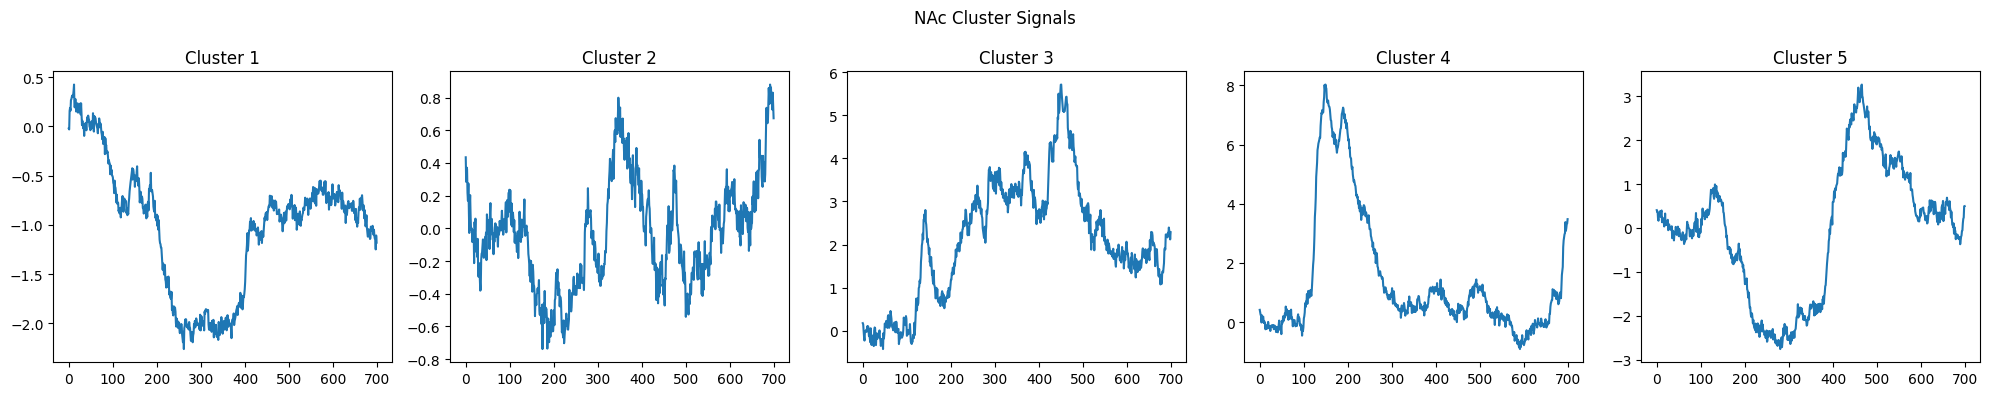

In [55]:
series1 = nac1
series2 = nac2
series3 = nac3
series4 = nac4
series5 = nac5

time = np.arange(699)

# Create figure and subplots
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('NAc Cluster Signals')

# Plot each series
ax1.plot(time, series1)
ax1.set_title('Cluster 1')

ax2.plot(time, series2)
ax2.set_title('Cluster 2')

ax3.plot(time, series3)
ax3.set_title('Cluster 3')

ax4.plot(time, series4)
ax4.set_title('Cluster 4')

ax5.plot(time, series5)
ax5.set_title('Cluster 5')

# Adjust layout and display
plt.tight_layout()
plt.show()